<a href="https://www.kaggle.com/code/lalit7881/oil-sales-dataset-eda-100?scriptVersionId=337552992" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mahmoudshaheen1134/oil-sales-dataset/oil_sales_assignment_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mahmoudshaheen1134/oil-sales-dataset/oil_sales_assignment_dataset.csv")

In [3]:
df.head()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,830.86,30.1,27.6
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,373.10,9.1,41.0
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,171.70,1.7,101.0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,1226.10,20.1,61.0
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,996.30,12.3,81.0


In [4]:
df.tail()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
1995,TABUK,HM No 99317 GS-CENTER-TABUK MAIN RD TABUK,NAJDI CONSUMER,LARA,COCONUT,0.5L,LARA COCONUT 0.5L PREMIUM,31-40,2024,11,74.4,2.4,31.0
1996,AL AHSA,HM No 85390 GS-CENTER-AL AHSA MAIN RD AL AHSA,BLUE OASIS CO,LARA,SUNFLOWER,3L,LARA SUNFLOWER 3L,31-40,2022,5,20.0,0.5,40.0
1997,AL KHARJ,HM No 90740 GS-CENTER-AL KHARJ MAIN RD AL K...,NOVA FOODS,NOUR,SUNFLOWER,2.9L,NOUR SUNFLOWER 2.9L,91-100,2023,8,527.8,5.8,91.0
1998,RIYADH,HM No 52893 GS-CENTER-RIYADH MAIN RD RIYADH,NOVA FOODS,NAJMA,CORN,0.75L,NAJMA CORN 0.75L ECO,61-70,2024,6,305.0,5.0,61.0
1999,JEDDAH,HM No 73689 GS-CENTER-JEDDAH MAIN RD JEDDAH,NAJDI CONSUMER,BAYTNA,COCONUT,1.8L,BAYTNA COCONUT 1.8L ECO,101+,2022,4,181.8,1.8,101.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           2000 non-null   object 
 1   store_name     2000 non-null   object 
 2   manufacturer   2000 non-null   object 
 3   brand          2000 non-null   object 
 4   class          2000 non-null   object 
 5   size           2000 non-null   object 
 6   sku            2000 non-null   object 
 7   price_bracket  2000 non-null   object 
 8   year           2000 non-null   int64  
 9   month          2000 non-null   int64  
 10  value_sales    2000 non-null   float64
 11  volume_sales   2000 non-null   float64
 12  average_price  2000 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 203.3+ KB


In [6]:
df.describe()

,year,month,value_sales,volume_sales,average_price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2022.990500,6.639500,614.839355,9.972100,60.990230
std,0.820211,3.468942,750.794991,9.862369,29.457029
min,2022.000000,1.000000,6.960000,0.500000,11.000000
25%,2022.000000,4.000000,132.000000,2.900000,37.337500
50%,2023.000000,7.000000,368.320000,7.000000,61.000000
75%,2024.000000,10.000000,794.100000,13.800000,81.000000
max,2024.000000,12.000000,6253.200000,81.700000,140.000000


In [7]:
df.isnull().sum()

city             0
store_name       0
manufacturer     0
brand            0
class            0
size             0
sku              0
price_bracket    0
year             0
month            0
value_sales      0
volume_sales     0
average_price    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

city              object
store_name        object
manufacturer      object
brand             object
class             object
size              object
sku               object
price_bracket     object
year               int64
month              int64
value_sales      float64
volume_sales     float64
average_price    float64
dtype: object

In [10]:
df.columns

Index(['city', 'store_name', 'manufacturer', 'brand', 'class', 'size', 'sku',
       'price_bracket', 'year', 'month', 'value_sales', 'volume_sales',
       'average_price'],
      dtype='object')

In [11]:
df.nunique()

city               12
store_name       1997
manufacturer        8
brand              10
class               5
size               13
sku              1571
price_bracket      10
year                3
month              12
value_sales      1306
volume_sales      349
average_price     149
dtype: int64

## EDA

Dataset Shape : (2000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           2000 non-null   object 
 1   store_name     2000 non-null   object 
 2   manufacturer   2000 non-null   object 
 3   brand          2000 non-null   object 
 4   class          2000 non-null   object 
 5   size           2000 non-null   object 
 6   sku            2000 non-null   object 
 7   price_bracket  2000 non-null   object 
 8   year           2000 non-null   int64  
 9   month          2000 non-null   int64  
 10  value_sales    2000 non-null   float64
 11  volume_sales   2000 non-null   float64
 12  average_price  2000 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 203.3+ KB
None
           city                                  store_name  \
count      2000                                        2000   
unique     

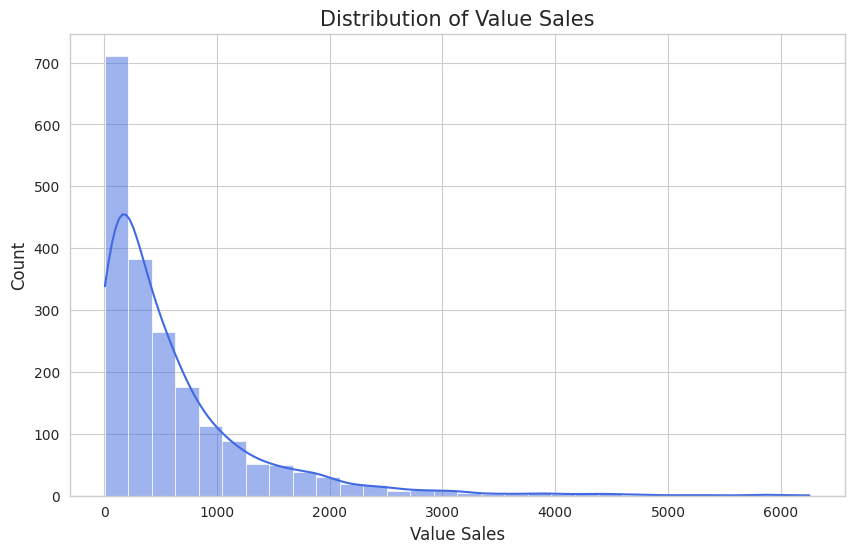

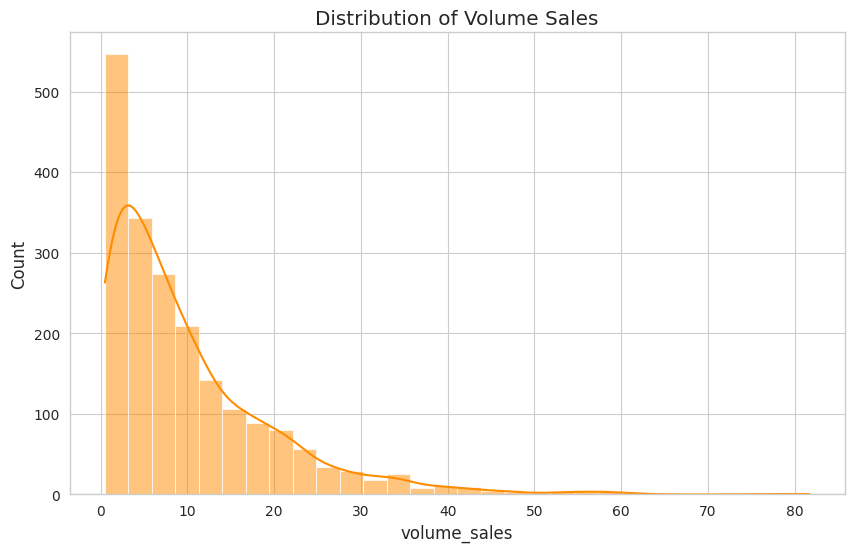

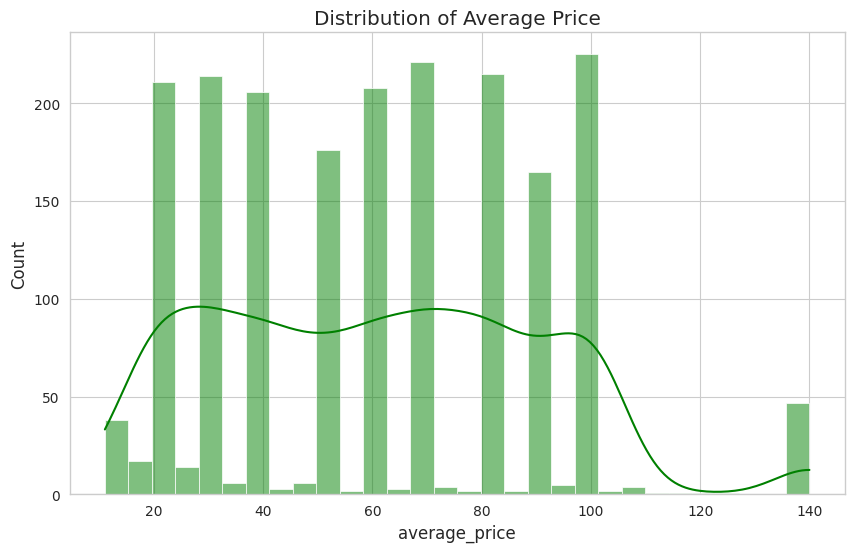

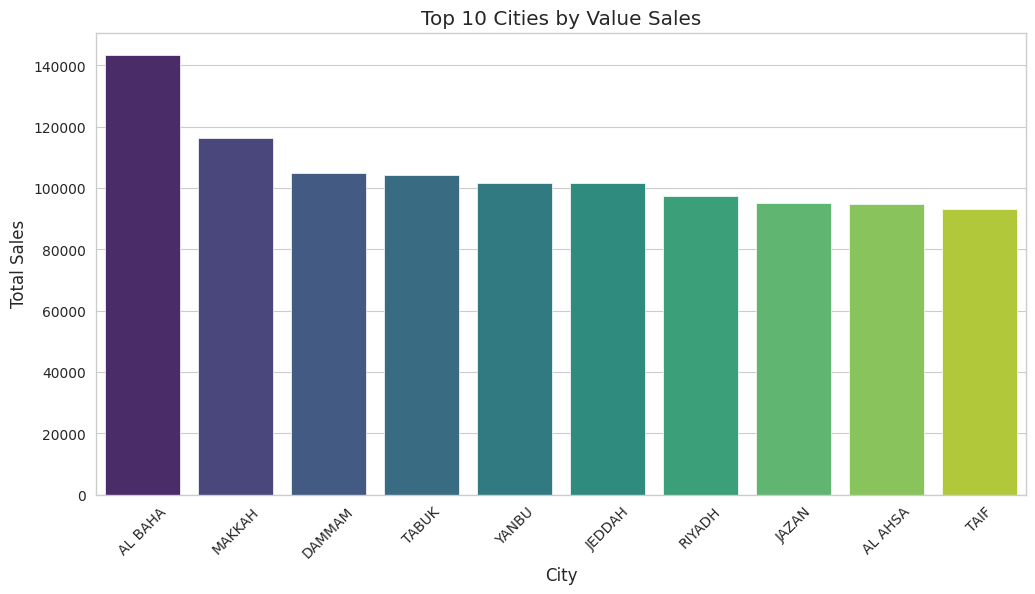

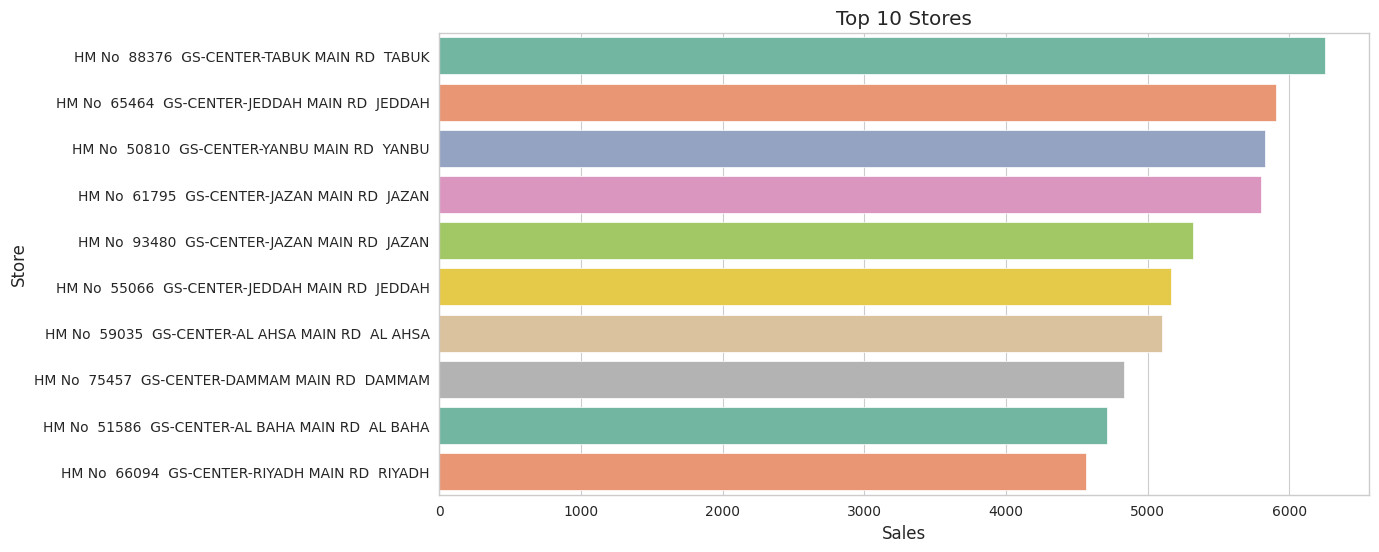

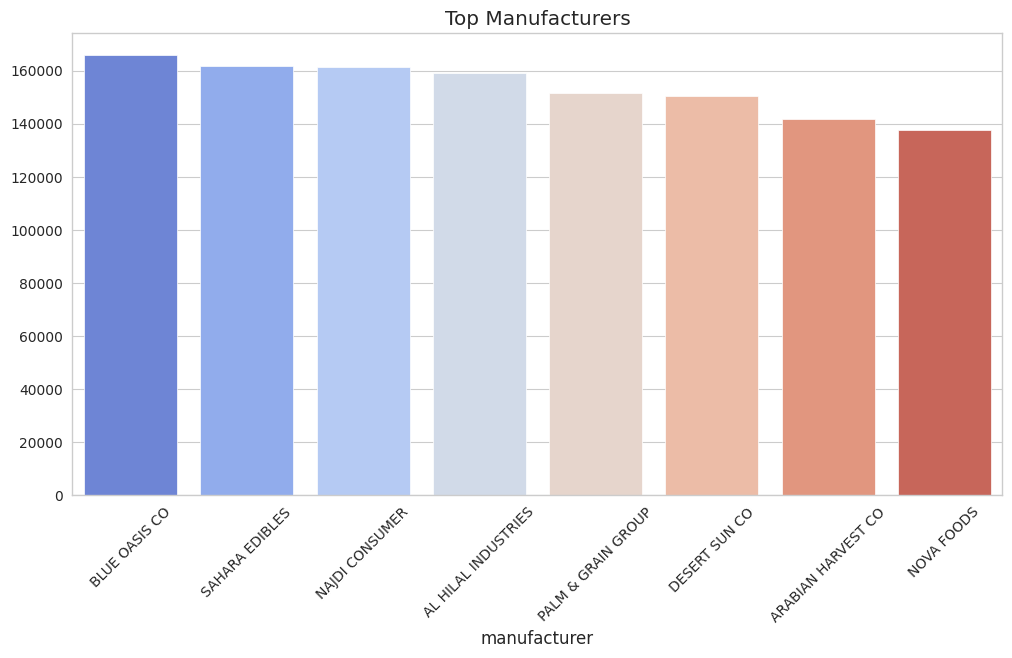

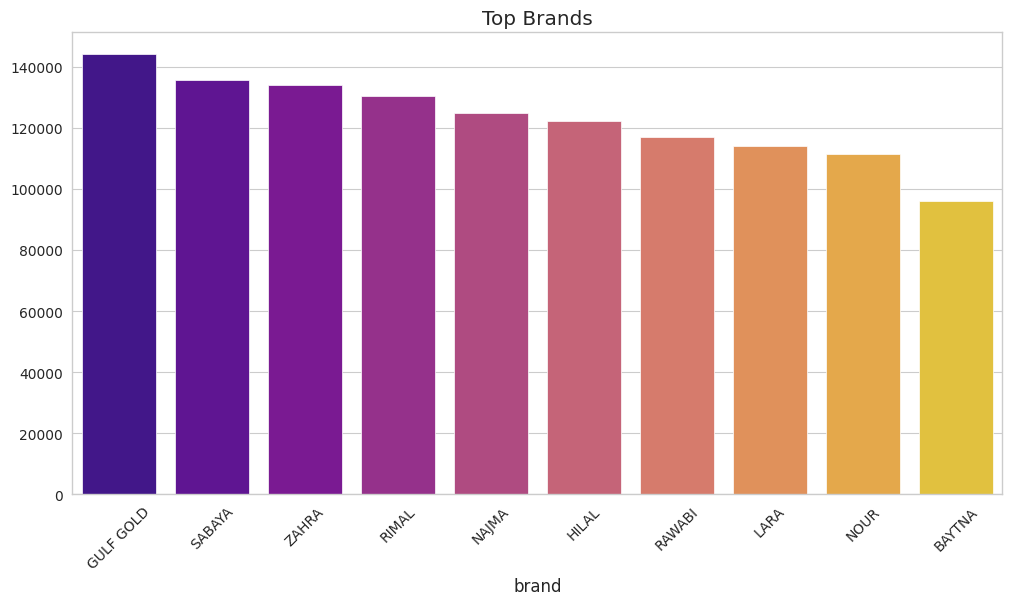

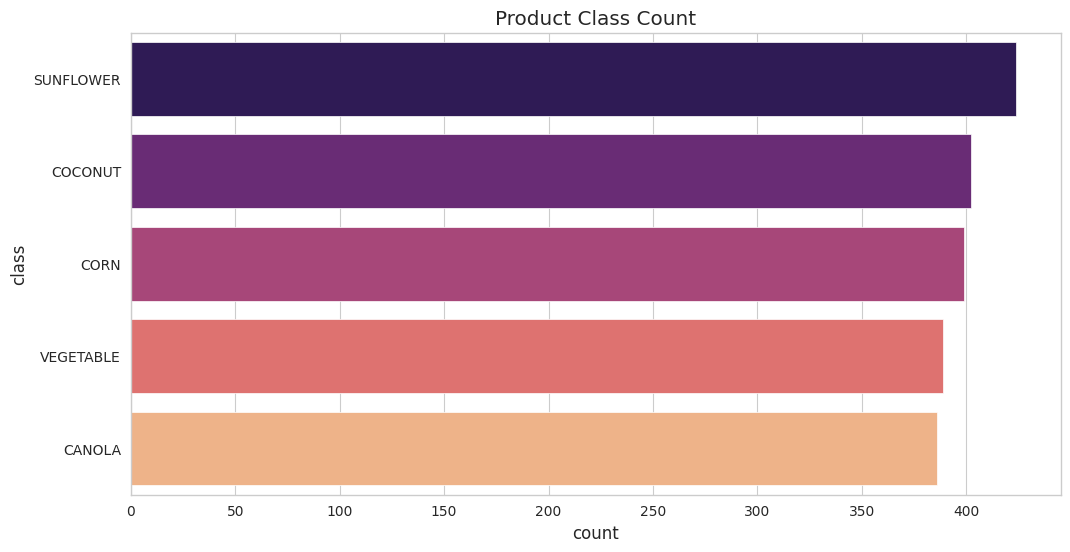

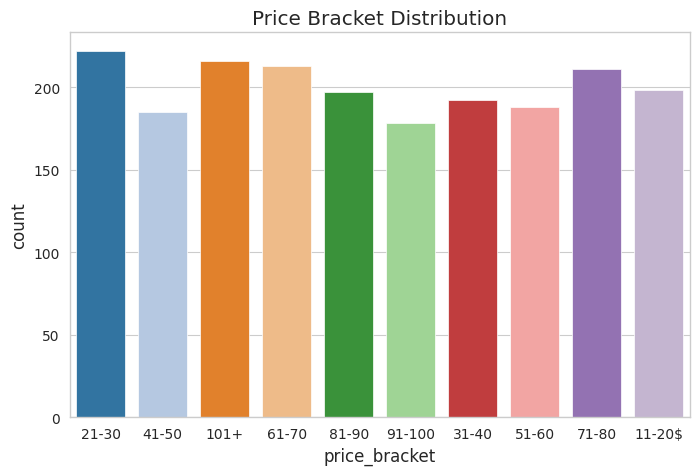

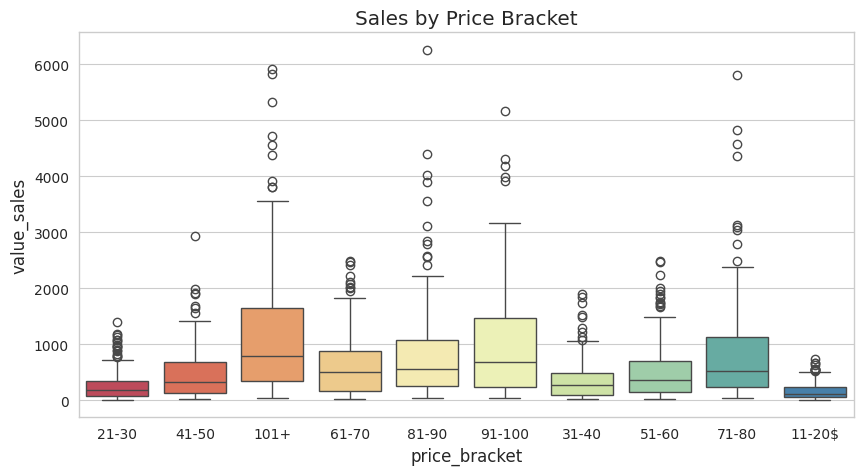

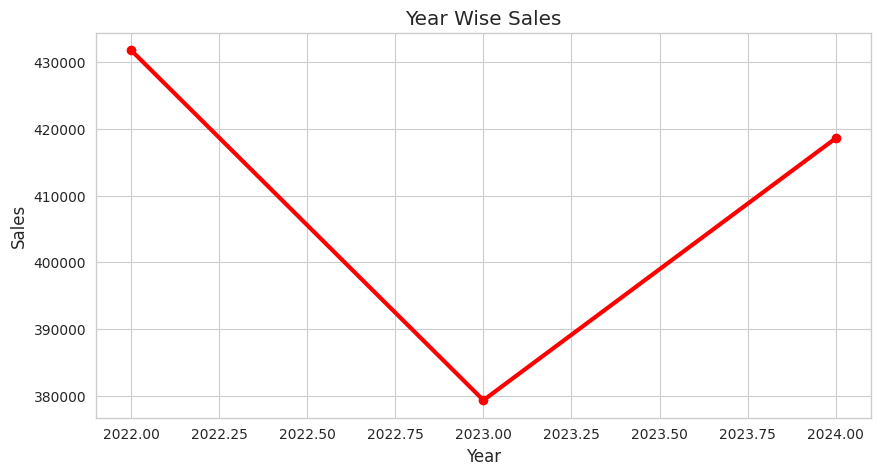

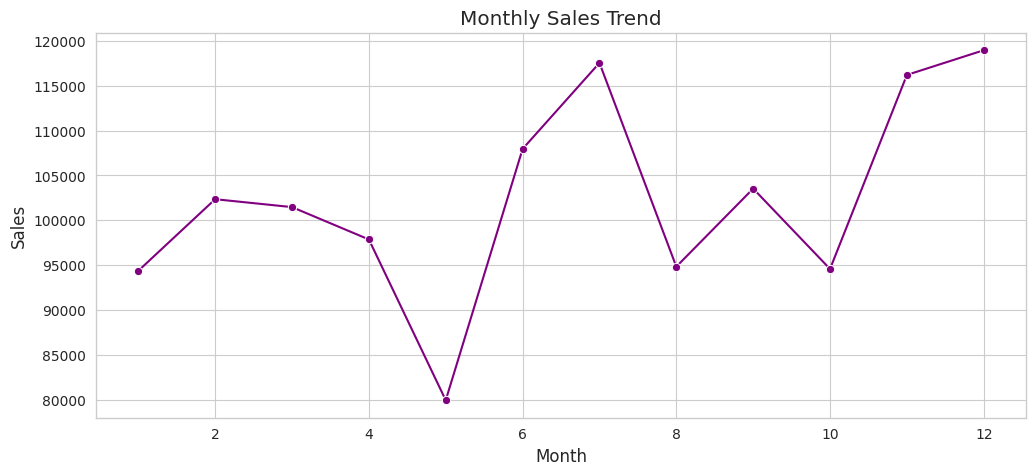

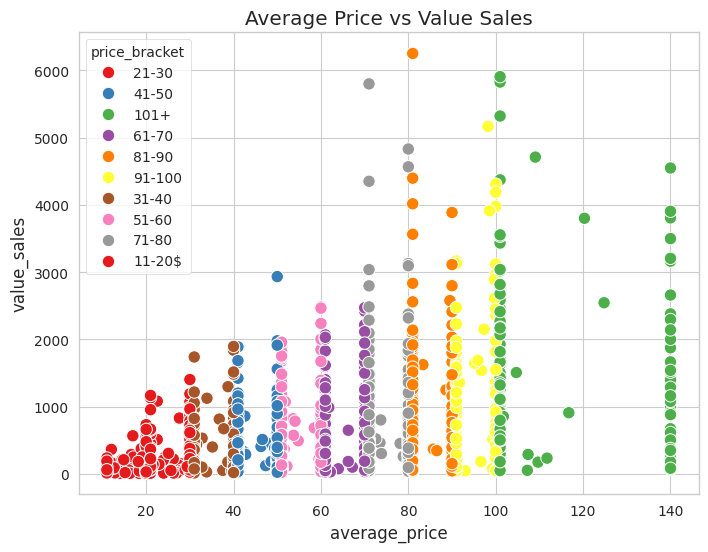

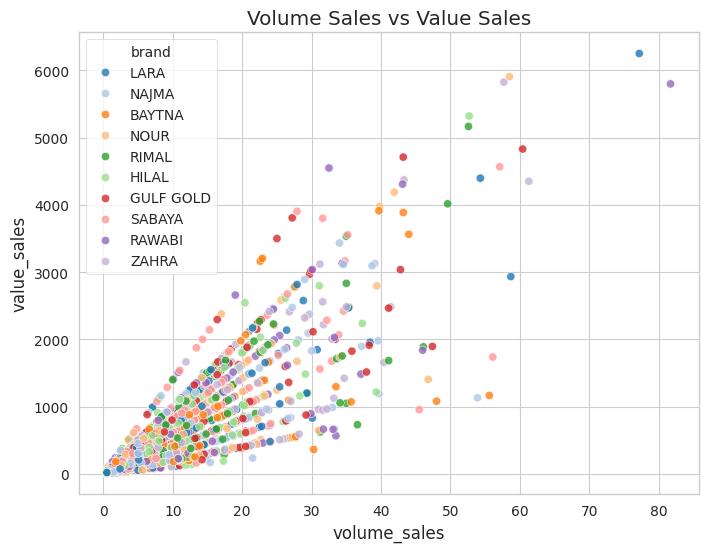

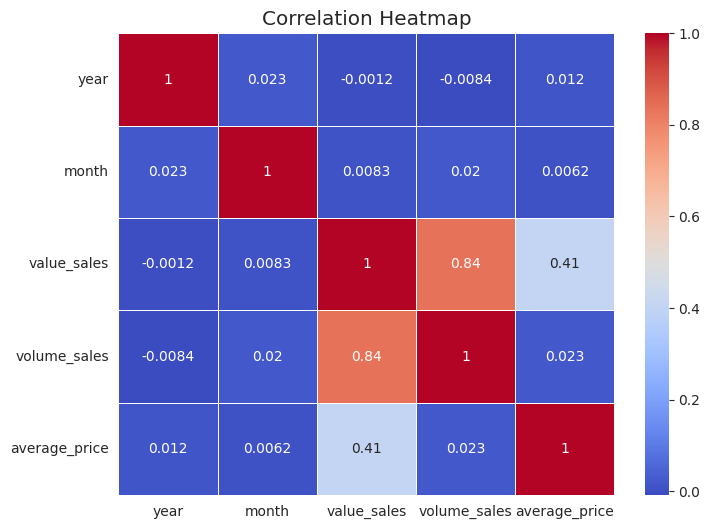

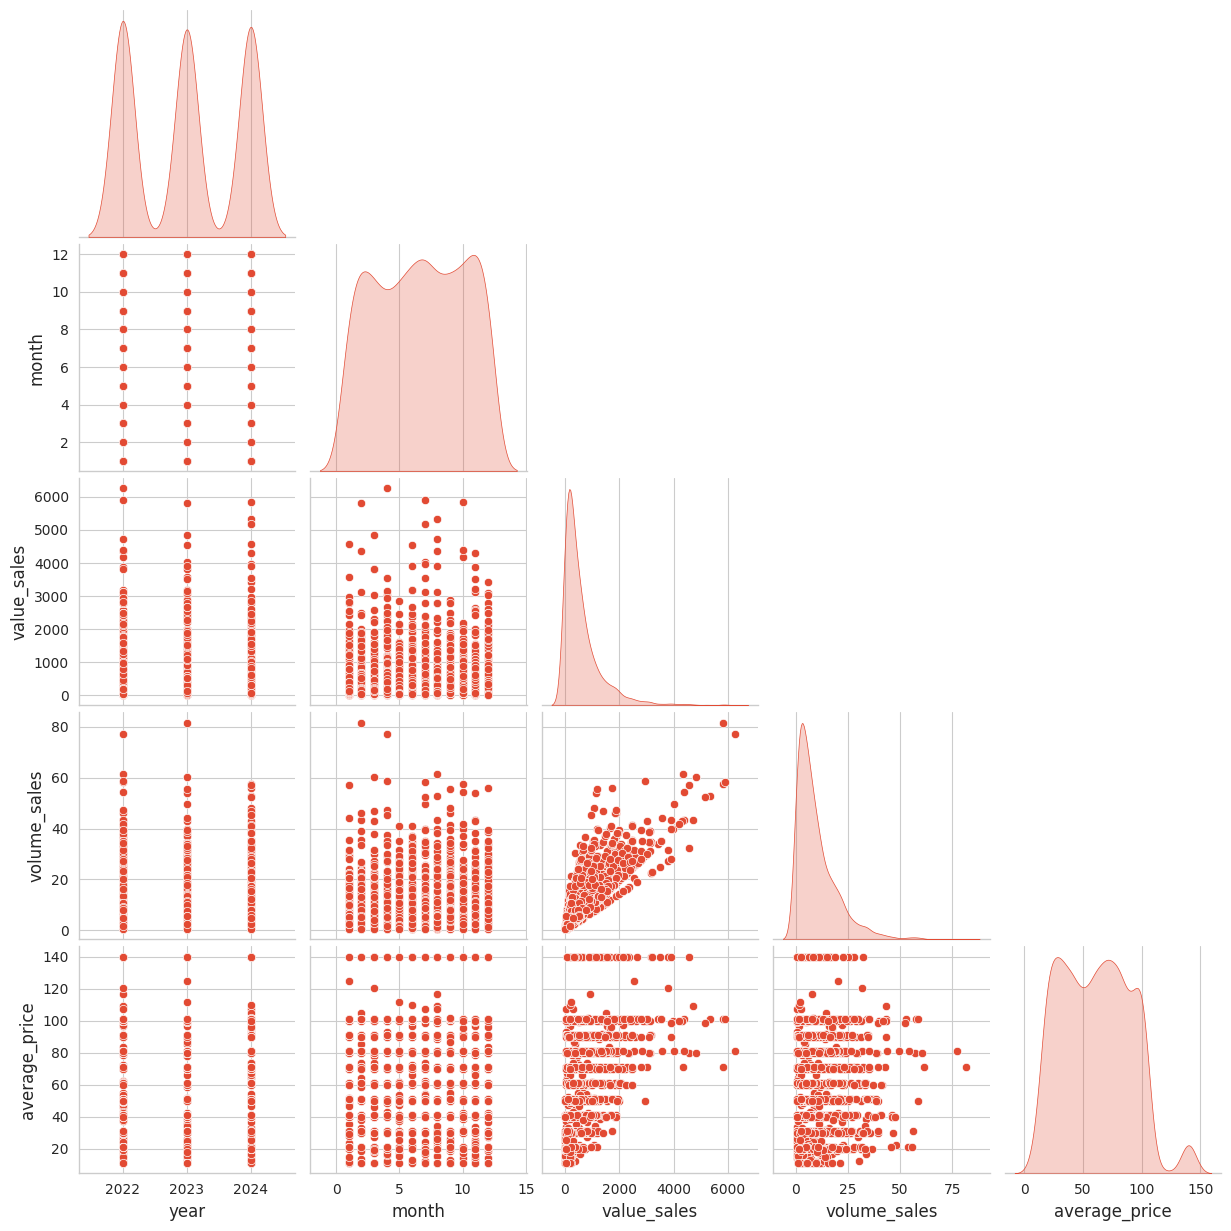

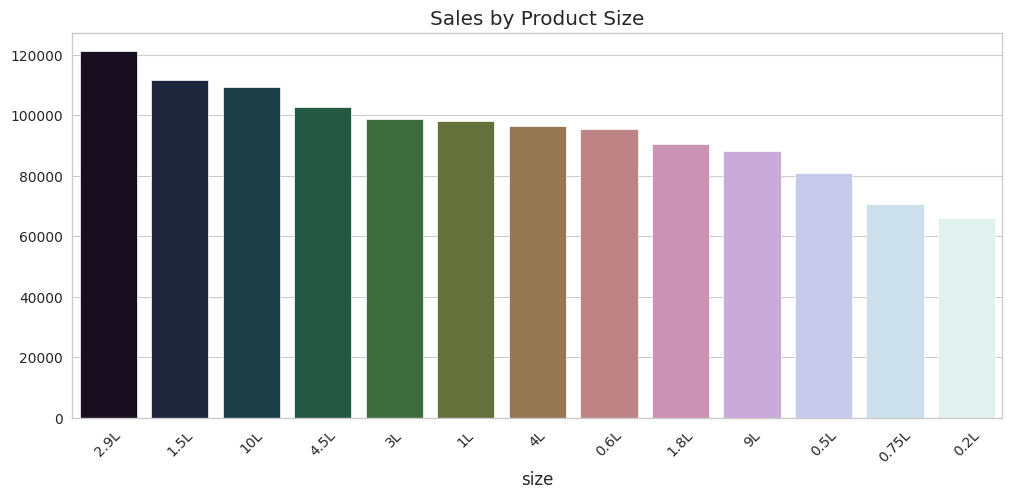

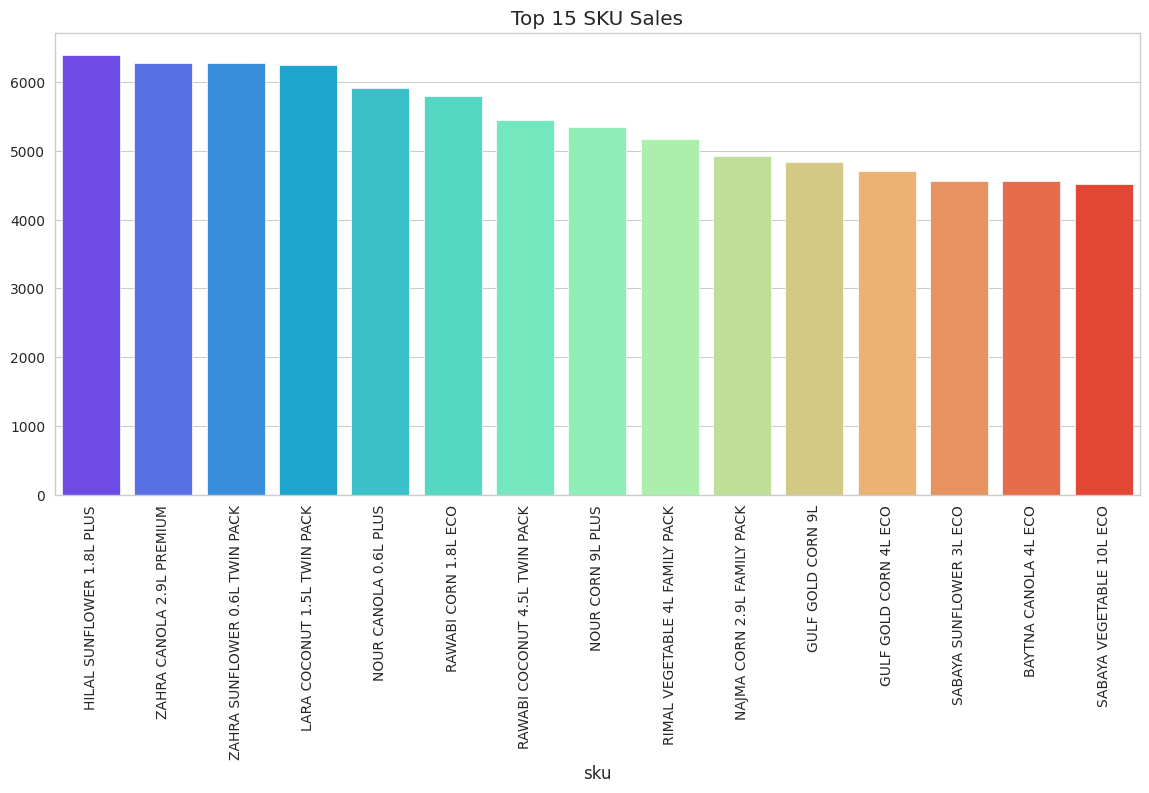

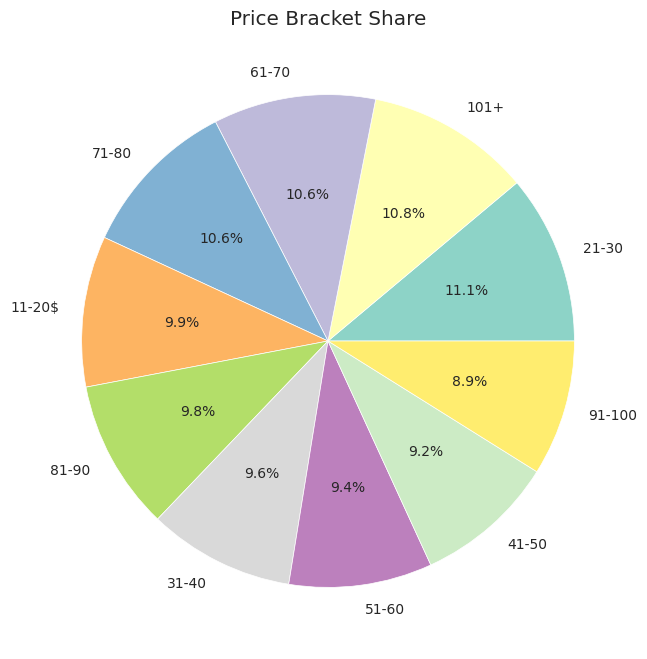

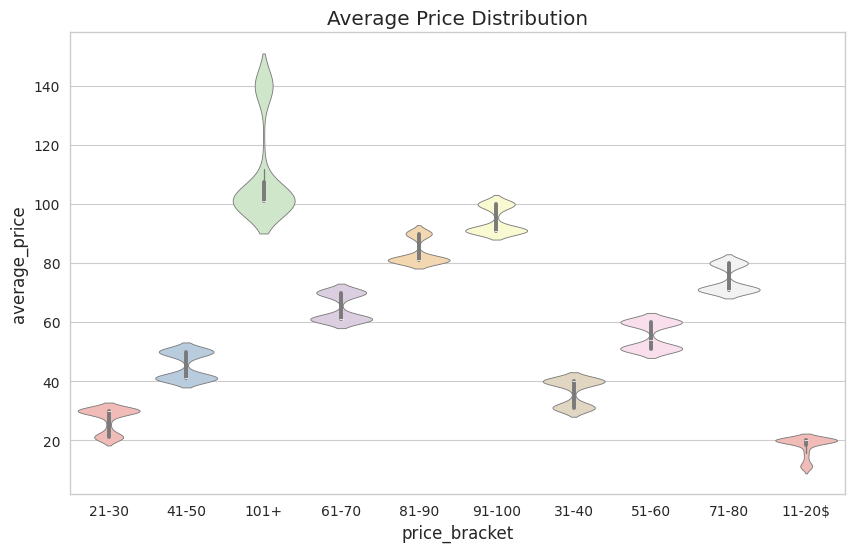

All Detailed EDA Visualizations Completed Successfully


In [12]:
#-----------------------------------------------------------
# Style
#-----------------------------------------------------------
plt.style.use("ggplot")
sns.set_style("whitegrid")

# Color Palettes
palette1 = "viridis"
palette2 = "Set2"
palette3 = "coolwarm"
palette4 = "plasma"
palette5 = "magma"
palette6 = "tab20"
palette7 = "Spectral"

#-----------------------------------------------------------
# Dataset Information
#-----------------------------------------------------------
print("="*60)
print("Dataset Shape :", df.shape)
print("="*60)

print(df.info())

print("="*60)
print(df.describe(include='all'))

print("="*60)
print("Missing Values")
print(df.isnull().sum())

#===========================================================
# Figure Size
#===========================================================
plt.rcParams["figure.figsize"]=(10,6)

#===========================================================
# 1. Value Sales Distribution
#===========================================================
plt.figure()
sns.histplot(df["value_sales"], bins=30, kde=True, color="royalblue")
plt.title("Distribution of Value Sales", fontsize=15)
plt.xlabel("Value Sales")
plt.ylabel("Count")
plt.show()

#===========================================================
# 2. Volume Sales Distribution
#===========================================================
plt.figure()
sns.histplot(df["volume_sales"], bins=30,
             kde=True,
             color="darkorange")
plt.title("Distribution of Volume Sales")
plt.show()

#===========================================================
# 3. Average Price Distribution
#===========================================================
plt.figure()
sns.histplot(df["average_price"],
             bins=30,
             kde=True,
             color="green")
plt.title("Distribution of Average Price")
plt.show()

#===========================================================
# 4. Top 10 Cities by Sales
#===========================================================
city_sales = df.groupby("city")["value_sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=city_sales.index,
    y=city_sales.values,
    palette=palette1
)
plt.xticks(rotation=45)
plt.title("Top 10 Cities by Value Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()

#===========================================================
# 5. Top Stores
#===========================================================
store_sales = df.groupby("store_name")["value_sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=store_sales.values,
    y=store_sales.index,
    palette=palette2
)

plt.title("Top 10 Stores")
plt.xlabel("Sales")
plt.ylabel("Store")
plt.show()

#===========================================================
# 6. Manufacturer Sales
#===========================================================
manufacturer_sales = df.groupby("manufacturer")["value_sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=manufacturer_sales.index,
    y=manufacturer_sales.values,
    palette=palette3
)
plt.xticks(rotation=45)
plt.title("Top Manufacturers")
plt.show()

#===========================================================
# 7. Brand Sales
#===========================================================
brand_sales = df.groupby("brand")["value_sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=brand_sales.index,
    y=brand_sales.values,
    palette=palette4
)
plt.xticks(rotation=45)
plt.title("Top Brands")
plt.show()

#===========================================================
# 8. Product Class Count
#===========================================================
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y="class",
    palette=palette5,
    order=df["class"].value_counts().index
)
plt.title("Product Class Count")
plt.show()

#===========================================================
# 9. Price Bracket Count
#===========================================================
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="price_bracket",
    palette=palette6
)
plt.title("Price Bracket Distribution")
plt.show()

#===========================================================
# 10. Sales by Price Bracket
#===========================================================
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x="price_bracket",
    y="value_sales",
    palette=palette7
)
plt.title("Sales by Price Bracket")
plt.show()

#===========================================================
# 11. Year Wise Sales
#===========================================================
year_sales = df.groupby("year")["value_sales"].sum()

plt.figure(figsize=(10,5))
plt.plot(
    year_sales.index,
    year_sales.values,
    marker="o",
    linewidth=3,
    color="red"
)
plt.title("Year Wise Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

#===========================================================
# 12. Monthly Sales
#===========================================================
month_sales = df.groupby("month")["value_sales"].sum()

plt.figure(figsize=(12,5))
sns.lineplot(
    x=month_sales.index,
    y=month_sales.values,
    marker="o",
    color="purple"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

#===========================================================
# 13. Average Price vs Sales
#===========================================================
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="average_price",
    y="value_sales",
    hue="price_bracket",
    palette="Set1",
    s=80
)
plt.title("Average Price vs Value Sales")
plt.show()

#===========================================================
# 14. Volume Sales vs Value Sales
#===========================================================
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="volume_sales",
    y="value_sales",
    hue="brand",
    palette="tab20",
    alpha=0.8
)
plt.title("Volume Sales vs Value Sales")
plt.show()

#===========================================================
# 15. Correlation Heatmap
#===========================================================
plt.figure(figsize=(8,6))

numeric = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    linewidth=0.5
)

plt.title("Correlation Heatmap")
plt.show()

#===========================================================
# 16. Pairplot
#===========================================================
sns.pairplot(
    numeric,
    corner=True,
    diag_kind="kde"
)
plt.show()

#===========================================================
# 17. Sales by Product Size
#===========================================================
size_sales = df.groupby("size")["value_sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(
    x=size_sales.index,
    y=size_sales.values,
    palette="cubehelix"
)

plt.xticks(rotation=45)
plt.title("Sales by Product Size")
plt.show()

#===========================================================
# 18. Top SKU Sales
#===========================================================
sku_sales = df.groupby("sku")["value_sales"].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(14,6))
sns.barplot(
    x=sku_sales.index,
    y=sku_sales.values,
    palette="rainbow"
)

plt.xticks(rotation=90)
plt.title("Top 15 SKU Sales")
plt.show()

#===========================================================
# 19. Pie Chart of Price Bracket
#===========================================================
plt.figure(figsize=(8,8))

df["price_bracket"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="Set3"
)

plt.ylabel("")
plt.title("Price Bracket Share")
plt.show()

#===========================================================
# 20. Violin Plot
#===========================================================
plt.figure(figsize=(10,6))
sns.violinplot(
    data=df,
    x="price_bracket",
    y="average_price",
    palette="Pastel1"
)

plt.title("Average Price Distribution")
plt.show()

print("="*60)
print("All Detailed EDA Visualizations Completed Successfully")
print("="*60)

> 

## Feature engineering

In [13]:

# Missing Values
# -----------------------------
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# -----------------------------
# Label Encoding
# -----------------------------
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

# -----------------------------
# Features & Target
# -----------------------------
X = df.drop("price_bracket", axis=1)
y = df["price_bracket"]

# -----------------------------
# Train Test Split
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Feature Scaling
# -----------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# ML Algorithms
# -----------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# -----------------------------
# Models
# -----------------------------
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "Extra Trees": ExtraTreesClassifier(),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB(),

    "SVM": SVC(probability=True),

    "AdaBoost": AdaBoostClassifier(),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="mlogloss"
    ),

    "LightGBM": LGBMClassifier(),

    "CatBoost": CatBoostClassifier(verbose=0)

}

# -----------------------------
# Evaluation
# -----------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average="weighted")
    recall = recall_score(y_test, pred, average="weighted")
    f1 = f1_score(y_test, pred, average="weighted")

    results.append([name,
                    accuracy*100,
                    precision*100,
                    recall*100,
                    f1*100])

    print("="*60)
    print(name)
    print("="*60)

    print(f"Accuracy : {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall   : {recall*100:.2f}%")
    print(f"F1 Score : {f1*100:.2f}%")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test,pred))

    print("\nClassification Report")
    print(classification_report(y_test,pred))

# -----------------------------
# Comparison Table
# -----------------------------
comparison = pd.DataFrame(results,
                          columns=[
                              "Model",
                              "Accuracy %",
                              "Precision %",
                              "Recall %",
                              "F1 Score %"
                          ])

comparison = comparison.sort_values(
    by="Accuracy %",
    ascending=False
)

print("\nModel Comparison")
print(comparison)

# -----------------------------
# Best Model
# -----------------------------
best_model = comparison.iloc[0]

print("\nBest Model")
print(best_model)

# -----------------------------
# Feature Importance
# -----------------------------
best = RandomForestClassifier()
best.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance")
print(importance)

Logistic Regression
Accuracy : 73.00%
Precision: 74.39%
Recall   : 73.00%
F1 Score : 72.45%

Confusion Matrix
[[31  0  0  0  0  0  0  0  0  1]
 [ 0 35  0  0  0  0  0  0  0  0]
 [ 0  4 41  1  0  0  0  0  0  0]
 [ 0  0  7 30  1  0  0  0  0  0]
 [ 0  0  0 10 27 12  0  0  0  0]
 [ 0  0  0  0  4 14 19  0  0  0]
 [ 0  0  0  0  0  2 32  3  0  0]
 [ 0  0  0  0  0  0 13 27  9  0]
 [ 0  0  0  0  0  0  0  5 28  6]
 [ 7  0  0  0  0  0  0  0  4 27]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.97      0.89        32
           1       0.90      1.00      0.95        35
           2       0.85      0.89      0.87        46
           3       0.73      0.79      0.76        38
           4       0.84      0.55      0.67        49
           5       0.50      0.38      0.43        37
           6       0.50      0.86      0.63        37
           7       0.77      0.55      0.64        49
           8       0.68      0.72      0.70      

## Thank you..pls upvote!!!!!!
